In [9]:

import torch
import scanpy as sc
import numpy as np
import os
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

from mmg.model import RMGE 

In [2]:
import mmg_sc

In [5]:
merged_data = sc.read_h5ad('test_data/mouse_human_brain_samp.h5ad')

In [6]:
sc.pp.normalize_total(merged_data, target_sum=1e4) 
sc.pp.log1p(merged_data)   

In [7]:
# #############################################optional#############################################
sc.pp.highly_variable_genes(merged_data, n_top_genes=3000)
merged_data = merged_data[:, merged_data.var['highly_variable']]

#############################################optional#############################################
# The number of cells must be greater than 500
# Suitable for Stereo seq, MERFISH, StarMAP and other technologies
#################################################################################################
# sn_data = merged_data[merged_data.obs['species']=='Human']
# st_data = merged_data[merged_data.obs['species']=='Mouse']

# sc.tl.pca(sn_data, n_comps=500)

# pca_weights = sn_data.varm['PCs']  # numpy array (n_genes, n_comps)

# st_matrix = torch.tensor(st_data.X.toarray()).float()  
# pca_weights_torch = torch.tensor(np.copy(pca_weights)).float()

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# st_matrix = st_matrix.to(device)
# pca_weights_torch = pca_weights_torch.to(device)

# st_pca = torch.matmul(st_matrix, pca_weights_torch).cpu().numpy().astype(np.float64)
# sn_data.obsm['X_pca'] = sn_data.obsm['X_pca'].astype(np.float64)

# st_pca_corr = []
# for i in range(st_pca.shape[1]):
#     pcs = (st_pca[:,i]-st_pca[:,i].mean())/st_pca[:,i].std()*sn_data.obsm['X_pca'][:,i].std()+sn_data.obsm['X_pca'][:,i].mean()
#     st_pca_corr.append(pcs)
# st_data.obsm['X_pca'] = np.array(st_pca_corr).T

# st_data_pca = sc.AnnData(X=st_data.obsm['X_pca'],obs=st_data.obs,obsm=st_data.obsm)
# sn_data_pca = sc.AnnData(X=sn_data.obsm['X_pca'],obs=sn_data.obs,obsm=sn_data.obsm)

# merged_data = sc.concat([sn_data_pca,st_data_pca])

In [8]:

refer_sp = 'Mouse'
query_sp = 'Human'

sub_merged_data1,sub_merged_data2 = merged_data[merged_data.obs['species']==refer_sp], merged_data[merged_data.obs['species']==query_sp]
sub_merged_data2.X = sub_merged_data2.X*(sub_merged_data1.X.mean(axis=0)/(sub_merged_data2.X.mean(axis=0)+1e-50))
rmge = RMGE(sub_merged_data1,sub_merged_data2, device='cuda',class_columns = 'SubClass',kl_weight=0)
train_losses, train_accuracies = rmge.train(epochs=500)

predict_class_names = rmge.evaluate()



Epoch 0/500, Loss: 14.907613754272461, Accuracy: 1.0
Epoch 100/500, Loss: 0.6718630790710449, Accuracy: 1.0
Epoch 200/500, Loss: 0.6065146327018738, Accuracy: 1.0
Epoch 300/500, Loss: 0.5991519689559937, Accuracy: 1.0
Epoch 400/500, Loss: 0.6005071401596069, Accuracy: 1.0
Validation Accuracy: 1.0000


Validation Accuracy: 1.0000


/tmp/ipykernel_52037/4212902695.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sub_merged_data2.obs['predict']=predict_class_names


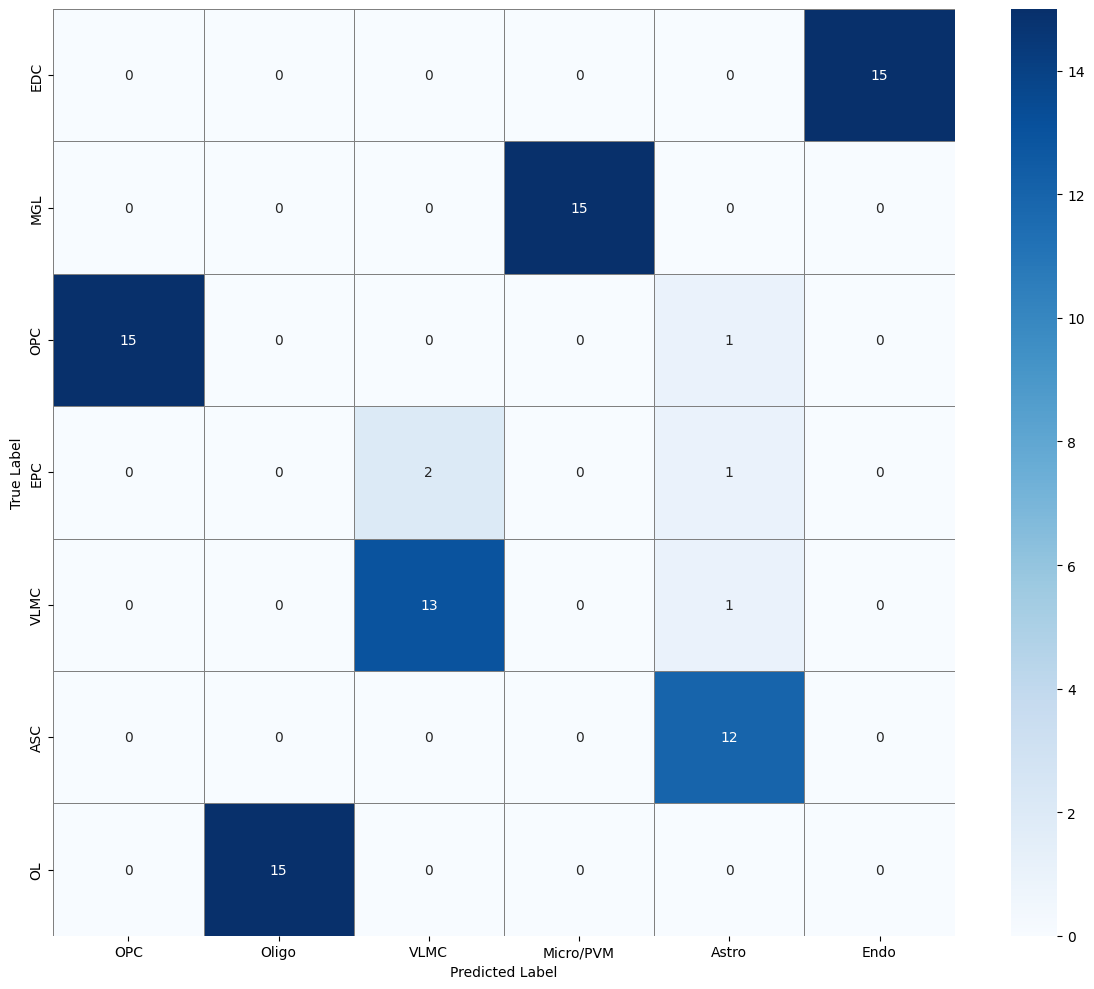

In [11]:
predict_class_names = rmge.evaluate()
sub_merged_data2.obs['predict']=predict_class_names

# 获取数据
true_labels = sub_merged_data2.obs['SubClass']
pred_labels = sub_merged_data2.obs['predict']

# 计算混淆矩阵
cm = confusion_matrix(true_labels, pred_labels)

# 创建标签列表（包含所有出现的类别）
classes = sorted(set(true_labels) | set(pred_labels))

# 转置混淆矩阵，使 true label 为列，pred label 为行
cm_df = pd.DataFrame(cm.T, index=classes, columns=classes)
cm_df = cm_df[list(set(true_labels))].loc[list(set(pred_labels))]
plt.figure(figsize=(12, 10))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, linecolor='gray')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()